In [ ]:
# imports 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from collections import Counter 
import nltk 
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize 
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import CountVectorizer
import os as os
import shutil as shutil
import glob
df = pd.read_csv("documents.csv")
from nltk.sentiment.vader import SentimentIntensityAnalyzer

True

In [124]:
collection_counts = df['Collections'].value_counts()

print("total number of txt files per Collection type:")
print(collection_counts.to_string())

total number of txt files per Collection type:
Collections
U.S. federal laws                                                         572
U.S. state and local documents                                            345
U.S. regulations, executive orders, and agency policies                    37
NDAA provisions;U.S. federal laws;FY2026 NDAA                              37
U.S. federal laws;NDAA provisions;FY2023 NDAA                              30
Chinese law and policy                                                     26
Miscellaneous documents                                                    25
U.S. federal laws;NDAA provisions;FY2021 NDAA                              24
NDAA provisions;FY2025 NDAA                                                23
U.S. federal laws;NDAA provisions;FY2024 NDAA                              22
Corporate policies and commitments                                         12
U.S. federal laws;NDAA provisions;FY2022 NDAA                              12
Multi

It looks like some txt files may belong to multiple Collections, or that there are disinct subcategories for some collections (ex.U.S. federal laws;NDAA provisions;FY2023 NDAA and U.S. federal laws;NDAA provisions;FY2022 NDAA). 

In [125]:

# filtering txt files by collection 

def get_agora_ids_by_collection(df, collections):
    """
    filters a .csv file by the given collection and returns a list of matching Agora IDs 
    """
     
    # clean whitespace 
    matched_rows = df[df['Collections'].astype(str).str.strip() == collections.strip()]
    
    # extract ids, drop nulls, convert to str 
    id_list = matched_rows['AGORA ID'].dropna().astype(str).tolist()
    
    return id_list


In [128]:

# extracting targeted collection 
target_collection = "U.S. federal laws"
matching_ids = get_agora_ids_by_collection(df, target_collection)
# id_string = ", ".join(str(id) for id in matching_ids)

# view results 
print(f"IDs found for '{target_collection}':", matching_ids)
print(f'total number of matches:  {len(matching_ids)}')


IDs found for 'U.S. federal laws': ['2571', '2641', '2643', '2623', '2620', '1307', '1221', '1016', '1205', '546', '986', '878', '822', '1007', '819', '1001', '881', '500', '820', '805', '795', '872', '422', '1219', '2875', '2887', '2833', '2837', '2841', '2906', '2900', '2832', '2835', '2919', '2815', '2881', '2917', '2848', '2889', '2828', '6309', '2883', '2838', '2863', '2824', '2825', '2878', '2884', '2862', '2891', '2892', '2921', '2856', '2810', '2819', '2911', '2854', '2870', '2902', '2914', '2888', '2840', '2808', '2930', '2936', '6676', '6677', '6675', '2898', '2932', '6681', '6770', '6773', '6776', '2806', '2804', '2802', '2801', '2800', '2797', '2793', '2788', '2784', '2778', '2776', '2772', '2770', '2764', '2760', '2752', '2748', '2746', '2742', '2737', '2726', '2494', '2492', '2490', '2487', '2485', '2474', '2473', '2471', '2470', '2461', '2459', '2451', '2449', '2444', '2443', '2430', '2428', '1929', '1344', '1242', '1201', '2476', '902', '2730', '1270', '1247', '1200', '

if id = id.txt, then do eda (word count, sentinment, frequency of words, length) 
or, if id = id.txt, then create a seperate folder with the all the txt files for collection name

In [ ]:
def group_collection_text_files(df, collection_name, source_folder="fulltext", output_base_folder="."):
    """
    looks inside the 'fulltext' subfolder for {id}.txt files matching a collection and copies them into a new collection folder.
    """

    # filter and extract integer IDs, drop NA's, make int, convert to list 
    matched_rows = df[df['Collections'].astype(str).str.strip() == collection_name.strip()]
    matching_ids = matched_rows['AGORA ID'].dropna().astype(int).tolist()
    
    print(f"found {len(matching_ids)} matching records in the documents csv for: '{collection_name}'")
    
    if not matching_ids:
        print("no matching IDs found for this collection name.")
        return matching_ids

    # 3. create destination folder 
    safe_folder_name = "".join(c for c in collection_name if c.isalnum() or c in (' ', '_', '-')).strip()
    destination_folder = os.path.join(output_base_folder, safe_folder_name)
    
    os.makedirs(destination_folder, exist_ok=True)
    print(f"created/verified destination folder at: '{destination_folder}'")
    
    # 4. search 'fulltext' folder and copy corresponding '{id}.txt' files
    copied_count = 0
    for agora_id in matching_ids:
        filename = f"{agora_id}.txt"
        
        # look INSIDE the fulltext subfolder
        source_file_path = os.path.join(source_folder, filename)
        # put INSIDE the newly created collection folder
        destination_file_path = os.path.join(destination_folder, filename)
        
        if os.path.exists(source_file_path):
            shutil.copy2(source_file_path, destination_file_path)
            copied_count += 1

    print(f"successfully copied {copied_count} out of {len(matching_ids)} text files into '{safe_folder_name}/'")
    return matching_ids



In [51]:
# running function 
target_collection = "U.S. regulations, executive orders, and agency policies"
matching_ids = group_collection_text_files(df, target_collection)


found 37 matching records in the documents csv for: 'U.S. regulations, executive orders, and agency policies'
created/verified destination folder at: './US regulations executive orders and agency policies'
successfully copied 37 out of 37 text files into 'US regulations executive orders and agency policies/'


EDA

In [116]:
def eda_function(folder_path, stop_words_lang = 'english'):
    '''
    reads all txt files in the collection folders and perfoms text EDA focusing 
    on word counts, file length, sentiment, and word frequencies
    '''
    search_path = os.path.join(folder_path, '*.txt')
    file_paths = glob.glob(search_path)

    print(f"text EDA report for folder: '{folder_path}'")
    print(f"total text files found: {len(file_paths)}")

    # metrics 
    data_metrics = []
    all_words_compiled = []
    stop_words_set = set(stopwords.words(stop_words_lang))

    for path in file_paths: 
        file_name = os.path.basename(path)
        # print(f"DEBUG: attempting to read file -> {file_name}")

        try: 
            with open(path, 'r', errors = 'ignore') as f:
                raw_text = f.read().strip()
        except Exception as e:
            print(f"read error on '{file_name}': {e}")
            continue 
        if not raw_text:
            print(f"SKIPPED: '{file_name}' is completely empty (0 characters).") 
            continue

        # convert text structure 
        char_counts = len(raw_text)
        words = word_tokenize(raw_text)
        sentences = sent_tokenize(raw_text)

        word_count = len(words)
        sentence_count = len(sentences)

        # avg word length 
        avg_word_length = np.mean([len(w) for w in words]) if word_count > 0 else 0

        # frequency analysis 
        clean_file_words = [w.lower() for w in words if w.isalpha()]
        all_words_compiled.extend(clean_file_words)

        # entry metrics 
        data_metrics.append({
            'file name' : file_name, 
            'charecter length': char_counts, 
            'word count': word_count,
            'sentence count': sentence_count, 
            'avg word length': avg_word_length, 
        })
        # print(f"parsed '{file_name}' successfully")

    metrics_df = pd.DataFrame(data_metrics)
    if metrics_df.empty: 
        print('warning: no readable data extracted from .txt files')
        return None
        
        # statistical summaries 
    print('length and summary profiles:')
    print(metrics_df[['charecter length', 'word count', 'sentence count', 'avg word length']].describe().to_string())


        # frequency 
    meaningful_words = [w for w in all_words_compiled if w not in stop_words_set]
    word_frequencies = Counter(meaningful_words)

    print('top 10 most frequent meaningful words, excluding stop words')
    for word, count in word_frequencies.most_common(10):
        print(f"  • {word}: {count}")
        
        # visualizations 
    fig, axes = plt.subplots(1,2, figsize = (10, 6))

        # word count distributions 
    sns.histplot(metrics_df['word count'], kde = True, ax = axes[0], color = 'blue', bins = 5)
    axes[0].set_title('distribution of file word counts')
    axes[0].set_xlabel('words per file')

        # file length 
    sns.histplot(metrics_df['charecter length'], kde = True,ax=axes[1], color='indigo', bins = 5 )
    axes[1].set_title('distribution of file character lengths')
    axes[1].set_xlabel('characters per file')

    plt.tight_layout()
    plt.show() 

    return metrics_df 
    

US state and local documents

text EDA report for folder: 'US state and local documents'
total text files found: 345
length and summary profiles:
       charecter length    word count  sentence count  avg word length
count        345.000000    345.000000      345.000000       345.000000
mean       10754.556522   1950.394203       55.860870         4.632397
std        10984.695933   2003.238873       56.724685         0.297351
min          329.000000     59.000000        1.000000         3.795673
25%         3768.000000    700.000000       19.000000         4.446234
50%         7205.000000   1301.000000       39.000000         4.615164
75%        13192.000000   2446.000000       70.000000         4.797587
max        70618.000000  12646.000000      449.000000         5.737485
top 10 most frequent meaningful words, excluding stop words
  • section: 4689
  • shall: 4673
  • intelligence: 3063
  • artificial: 3057
  • state: 2649
  • ai: 2552
  • information: 2463
  • use: 2431
  • b: 2319
  • system: 2206


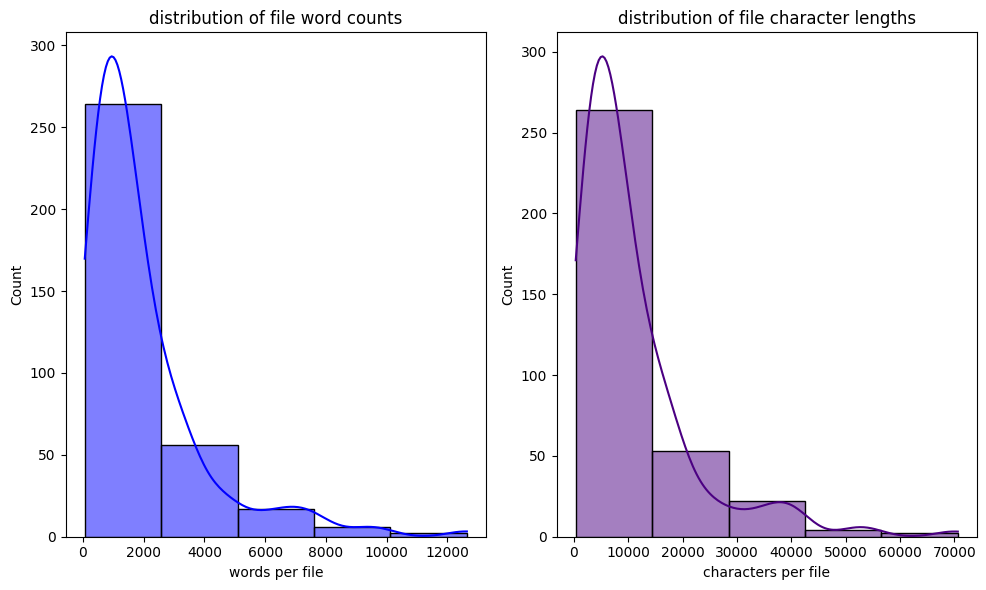

In [117]:
folder_to_analyze = "US state and local documents"
analysis_results_df = eda_function(folder_path=folder_to_analyze)

US regulations executive orders and agency policies

text EDA report for folder: 'US regulations executive orders and agency policies'
total text files found: 37
length and summary profiles:
       charecter length    word count  sentence count  avg word length
count         37.000000     37.000000       37.000000        37.000000
mean       21206.621622   3701.837838      101.216216         4.831365
std        27021.611165   4537.846403      123.368269         0.314888
min          874.000000    163.000000        7.000000         3.735101
25%         3446.000000    610.000000       21.000000         4.612097
50%        10496.000000   1773.000000       51.000000         4.860370
75%        30116.000000   5064.000000      135.000000         5.053120
max       138992.000000  22344.000000      608.000000         5.336153
top 10 most frequent meaningful words, excluding stop words
  • ai: 1762
  • use: 550
  • data: 519
  • agencies: 444
  • must: 431
  • information: 428
  • systems: 420
  • may: 413
  • including: 389
  • federal: 303


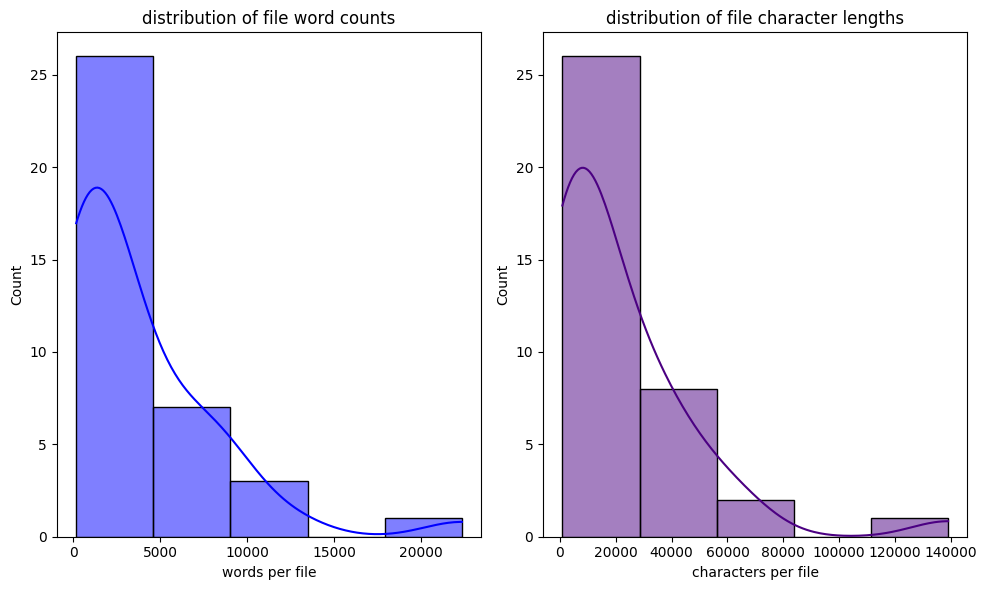

In [118]:
folder_to_analyze = "US regulations executive orders and agency policies"
analysis_results_df = eda_function(folder_path=folder_to_analyze)

US regulations executive orders and agency policies

text EDA report for folder: 'US regulations executive orders and agency policies'
total text files found: 37
length and summary profiles:
       charecter length    word count  sentence count  avg word length
count         37.000000     37.000000       37.000000        37.000000
mean       21206.621622   3701.837838      101.216216         4.831365
std        27021.611165   4537.846403      123.368269         0.314888
min          874.000000    163.000000        7.000000         3.735101
25%         3446.000000    610.000000       21.000000         4.612097
50%        10496.000000   1773.000000       51.000000         4.860370
75%        30116.000000   5064.000000      135.000000         5.053120
max       138992.000000  22344.000000      608.000000         5.336153
top 10 most frequent meaningful words, excluding stop words
  • ai: 1762
  • use: 550
  • data: 519
  • agencies: 444
  • must: 431
  • information: 428
  • systems: 420
  • may: 413
  • including: 389
  • federal: 303


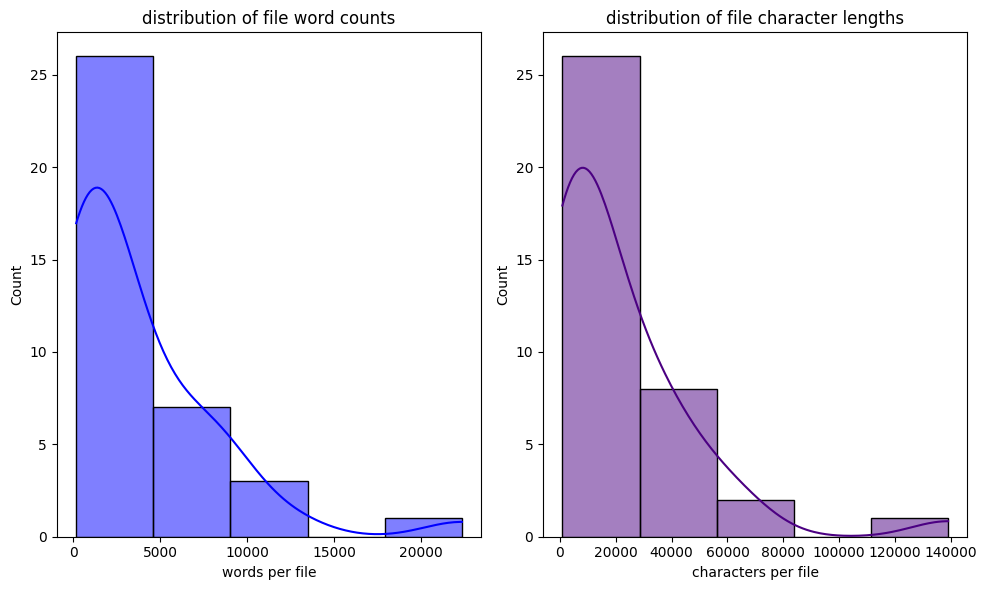

In [119]:
folder_to_analyze = "US regulations executive orders and agency policies"
analysis_results_df = eda_function(folder_path=folder_to_analyze)

In [135]:
# sentiment analysis function 

def sentiment_analyzer(folder_path):
    ''' 
    reads all .txt foles is a secpfic folder, calculates VADER sentiment score 
    for each file, prints summary
    '''
    search_path = os.path.join(folder_path, '*.txt')
    file_paths = glob.glob(search_path)

    print (f"sentiment analysis for folder: '{folder_path}")
    print(f'total text files found: {len(file_paths)}')

    if not file_paths: 
        print('no .txt files found in this directory')
        return None 
    
    # initalize 
    sia = SentimentIntensityAnalyzer()
    sentiment_data = []

    for path in file_paths: 
        file_name = os.path.basename(path)

        try: 
            with open(path, 'r', errors = 'ignore') as f:
                raw_text = f.read().strip() 
        except Exception as e: 
            print(f"read error on '{file_name}': {e} ")
            continue
        if not raw_text: 
            continue 

        # VADAR scores 
        scores = sia.polarity_scores(raw_text)

        # classifier 

        if scores['compound'] >= 0.05:
            stance = 'Positive'
        elif scores['compound'] <= -0.05:
            stance = 'Negative'
        else:
            stance = 'Neutral'
            
        sentiment_data.append({
            'file name': file_name, 
            'negative score': scores['neg'],
            'neutral score': scores['neu'],
            'positive score': scores['pos'], 
            'compound score': scores['compound'], 
            'overall stance': stance })
        
    # make df
    sentiment_df = pd.DataFrame(sentiment_data) 

    # show summary data

    # numerical summaries 
    print('sentiment intensity metrics summary')
    print(sentiment_df[['negative score', 'neutral score', 'positive score', 'compound score']].describe().to_string())
    
    # categorical distributions 
    print('categorical distributions ')
    print(sentiment_df['overall stance'].value_counts().to_string())

    # 3. graphs 
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # compound score 
    sns.histplot(sentiment_df['compound score'], kde=True, ax=axes[0], color='blue', bins=10)
    axes[0].set_title('distribution of compound sentiment scores')
    axes[0].set_xlabel('compound score (-1 = negative to +1 = positive)')
    
    # categorical breakdown 
    sns.countplot(data=sentiment_df, x='overall stance', hue = 'overall stance' , ax=axes[1], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
    axes[1].set_title('document stance classification counts')
    axes[1].set_xlabel('stance category')
    axes[1].set_ylabel('number of files')
    
    plt.tight_layout()
    plt.show()
    
    return sentiment_df





sentiment analysis for folder: 'US regulations executive orders and agency policies
total text files found: 37
sentiment intensity metrics summary
       negative score  neutral score  positive score  compound score
count       37.000000      37.000000       37.000000       37.000000
mean         0.031865       0.876459        0.091703        0.901476
std          0.020150       0.045143        0.037764        0.257008
min          0.000000       0.784000        0.047000       -0.440600
25%          0.016000       0.855000        0.062000        0.927900
50%          0.031000       0.877000        0.083000        0.997800
75%          0.043000       0.916000        0.113000        0.999800
max          0.083000       0.953000        0.185000        1.000000
categorical distributions 
overall stance
Positive    36
Negative     1


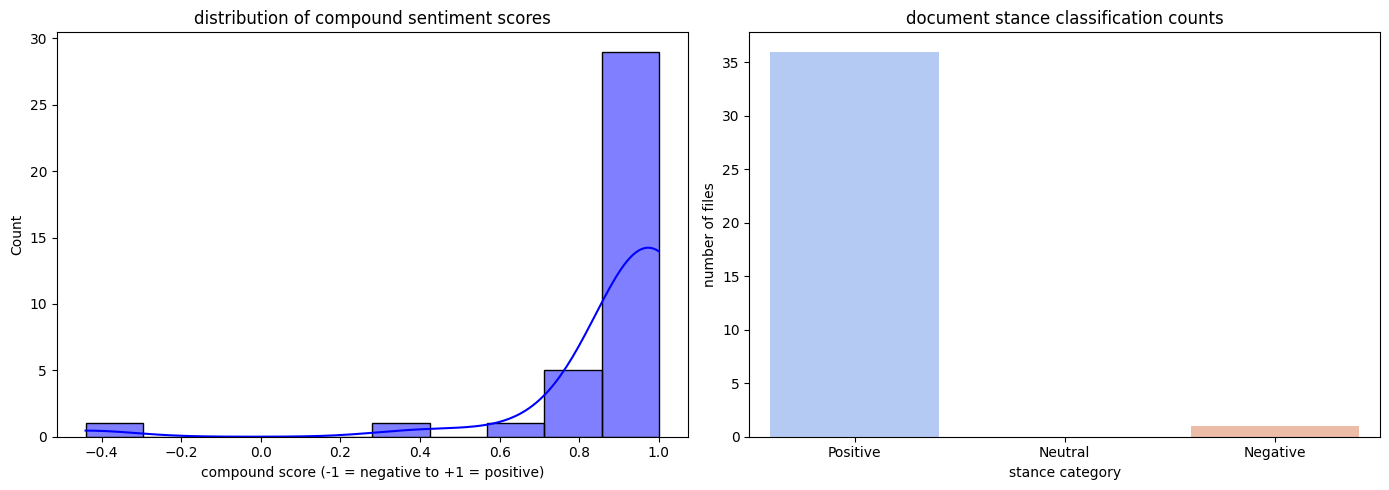

In [138]:

target_folder = "US regulations executive orders and agency policies"

sentiment_results_df = sentiment_analyzer(folder_path=target_folder)